# Inhalt aus: `B900-xai-titanic.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
eXplainable Artificial Intelligence (XAI) - Titanic
</b></font> </br></p>

---


with DALEX (moDel Agnostic Language for Exploration and eXplanation)

[DALEX](https://github.com/ModelOriented/DALEX)
[DrWhy.AI](https://github.com/ModelOriented/DrWhy/blob/master/README.md)

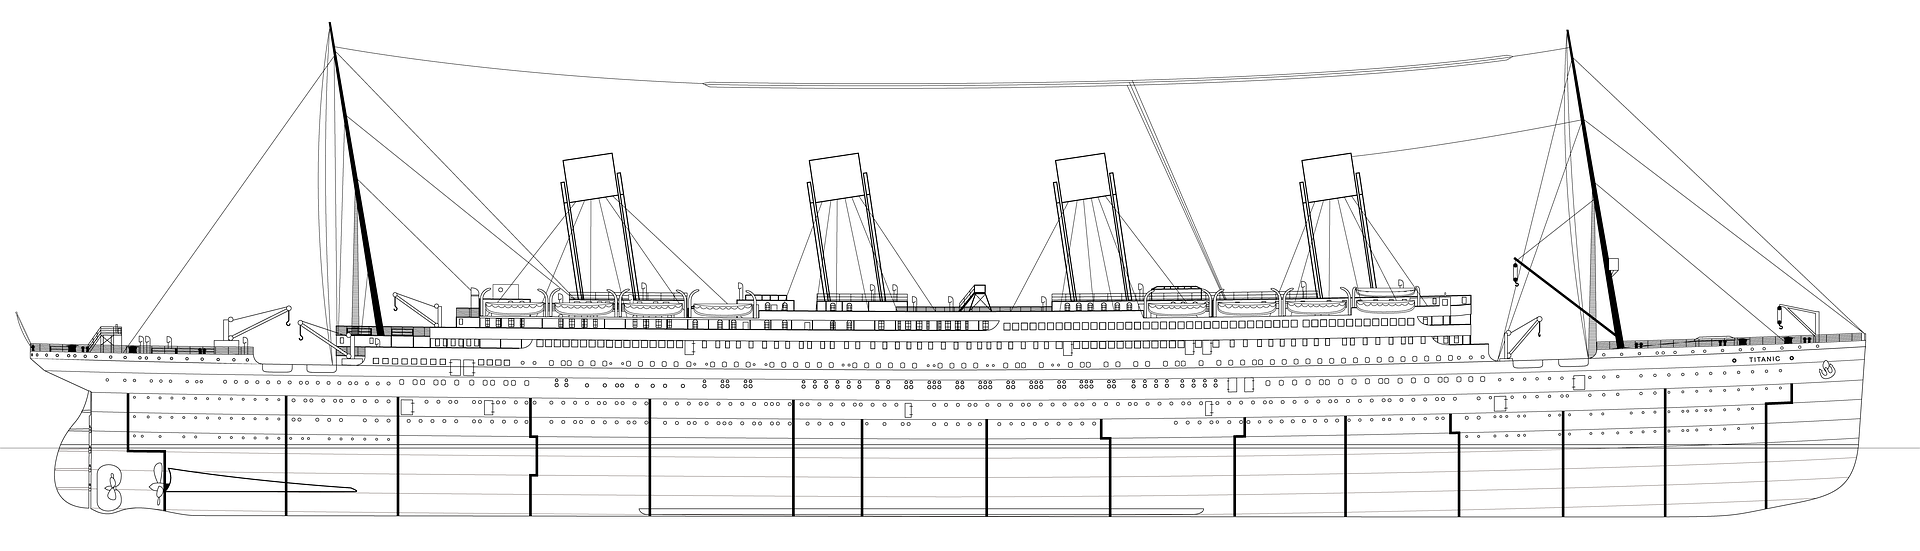

Bild von <a href="https://pixabay.com/de/users/axonia-14892766/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">axonia</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install
!uv pip install --system -q dalex -U
!uv pip install --system -q numpy scipy -U

In [ ]:
# Import
from pandas import read_csv, DataFrame

from sklearn.preprocessing import StandardScaler, OneHotcoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import dalex as dx

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">
Anwendungsfall
</font></p>

Dies ist der legendäre Titanic ML-Wettbewerb – die beste erste Herausforderung, um in ML-Modellierung einzutauchen.

Die Aufgabe ist einfach: Verwenden Sie maschinelles Lernen, um ein Modell zu erstellen, das vorhersagt, welche Passagiere den Schiffbruch der Titanic überlebt haben.

Wie lassen sich die Ergebnisse nachvollziehbar erklären.


[Titanic Org](https://www.encyclopedia-titanica.org/)

[DataSet](https://www.openml.org/search?type=data&status=active&id=40945)

[Info](https://www.kaggle.com/competitions/titanic/data)



In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Titanic.csv",
    usecols=["pclass", "survived", "sex", "age", "sibsp", "parch"],
)

In [ ]:
data = df.copy()
target = data.pop("survived")

In [ ]:
data.groupby("pclass").count()

In [ ]:
target.value_counts()

In [ ]:
data.head(-5)

# **2 | Prepare**

---


<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns


<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotcoder(handle_unknown="ignore")),
    ]
)


<p><font color='black' size="5">
Skalierung
</font></p>

In [ ]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())]
)


<p><font color='black' size="5">
Pipeline
</font></p>

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, num_col),
        ("cat", categorical_transformer, cat_col),
    ]
)


<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.20, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">
Modellauswahl
</font></p>

In [ ]:
classifier = MLPClassifier(
    hidden_layer_sizes=(150, 100, 50), max_iter=500, random_state=42
)

In [ ]:
model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", classifier)])

<p><font color='black' size="5">
Training
</font></p>

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---


<p><font color='black' size="5">
Accuracy, Cohen's Kappa, Confusion Matrix
</font></p>

In [ ]:
# @title
# @markdown <p><font size="5" color='grey'> <b> Code </b></font> </br></p>
def evaluate(model, data_train, data_test, target_train, target_test):
    # ---
    target_train_pred = model.predict(data_train)
    target_test_pred = model.predict(data_test)
    target_pred = model.predict(data)
    # ---
    acc_train = accuracy_score(target_train, target_train_pred) * 100
    cks_train = cohen_kappa_score(target_train, target_train_pred)
    print(f"Train -- Accuracy: {acc_train:5.2f}%, Cohen's Kappa: {cks_train:5.2f}")
    # ---
    acc_test = accuracy_score(target_test, target_test_pred) * 100
    cks_test = cohen_kappa_score(target_test, target_test_pred)
    print(f"Test -- Accuracy: {acc_test:5.2f}%, Cohen's Kappa: {cks_test:5.2f}")
    # ---
    acc_all = accuracy_score(target, target_pred) * 100
    cks_all = cohen_kappa_score(target, target_pred)
    print(f"All -- Accuracy: {acc_all:5.2f}, Cohen's Kappa: {cks_all:5.2f}")
    print("\n")
    # ---
    conf_matrix = confusion_matrix(target_test, target_test_pred)
    display_labels_ = ["Not Survived", "Survived"]
    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
    disp.plot(cmap="Blues")
    print(
        classification_report(
            target_test, target_test_pred, target_names=display_labels_
        )
    )
    # ---
    result = data_test.copy()
    result["target"] = target_test
    result["target_pred"] = target_test_pred

In [ ]:
evaluate(model, data_train, data_test, target_train, target_test)

# 5 | Deploy
---

# **A | XAI - Local Explanations**
---


<p><font color='black' size="5">
Explanation for Single Predictions
</font></p>


In [ ]:
exp = dx.Explainer(model, data, target)

In [ ]:
data.columns

<p><font color='black' size="5">
Prognose für Rose DeWitt Bukater und Jack Dawson
</font></p>

In [ ]:
rose = DataFrame(
    {"pclass": [1], "sex": ["female"], "age": [22], "sibsp": [0], "parch": [1]},
    index=["Rose"],
)

rose_pred = float(exp.predict(rose)) * 100
print(f"Prognose: Rose wird gerettet: {rose_pred:.2f}%")

In [ ]:
jack = DataFrame(
    {"pclass": [3], "sex": ["male"], "age": [23], "sibsp": [0], "parch": [0]}
)

jack_pred = float(exp.predict(jack)) * 100
print(f"Prognose: Jack wird gerettet: {jack_pred:.2f}%")

<p><font color='black' size="5">
Erläuterung der Prognose für Rose
</font></p>


[Break Down](https://pbiecek.github.io/ema/breakDown.html)

Welche Variablen tragen am meisten zu diesem Ergebnis bei?  Zerlegung der Vorhersage des Modells in Beiträge, die verschiedenen erklärenden Merkmale zugeordnet werden können.

In [ ]:
bd_rose = exp.predict_parts(rose, type="break_down", label=rose.index[0])
bd_plus_rose = exp.predict_parts(
    rose, type="break_down_interactions", label="Rose Plus"
)

In [ ]:
bd_rose.result

In [ ]:
bd_rose.plot()

[Break Down plus](https://pbiecek.github.io/ema/iBreakDown.html)


Berücksichtigung von Interaktionen zwischen den Merkmalen.

In [ ]:
bd_plus_rose.plot()

[Shapley Values](https://pbiecek.github.io/ema/shapley.html)


Die Wert der Beiträge eines Merkmals wird über alle (oder eine große Anzahl) möglicher Ordnungen zu mitteln. Die Idee ist eng mit den „Shapley-Werten“ verknüpft, die ursprünglich für kooperative Spiele entwickelt wurden (Shapley 1953 )

In [ ]:
sh_rose = exp.predict_parts(rose, type="shap", B=10, label=rose.index[0])
sh_rose.result.loc[sh_rose.result.B == 0,]
sh_rose.plot(bar_width=16)

[Individual Profile / Ceteris Paribus Profiles](https://pbiecek.github.io/ema/ceterisParibus.html)

In [ ]:
cp_rose = exp.predict_profile(rose, label=rose.index[0])
cp_jack = exp.predict_profile(jack, label=jack.index[0])
cp_rose.result.head()

In [ ]:
cp_rose.plot(cp_jack)

In [ ]:
cp_rose.plot(cp_jack, variable_type="categorical")

# **B | XAI - Gobal Explanations**
---
Explanation on Model Level

<p><font color='black' size="5">
Modellperformance
</font></p>

[Model Performance](https://pbiecek.github.io/ema/modelPerformance.html)

In [ ]:
mp = exp.model_performance(model_type="classification")
mp.result

In [ ]:
mp.plot(geom="roc")

<p><font color='black' size="5">
Wichtigkeit der Merkmale für einzelne Merkmale & Merkmalsgruppen
</font></p>


Bild von <a href="https://pixabay.com/de/users/thedigitalartist-202249/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1276873">Pete Linforth</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1276873">Pixabay</a>

In [ ]:
vi = exp.model_parts()
vi.result

In [ ]:
vi.plot(max_vars=5)

In [ ]:
vi_grouped = exp.model_parts(
    variable_groups={"personal": ["sex", "age", "sibsp", "parch"], "status": ["pclass"]}
)
vi_grouped.result

In [ ]:
vi_grouped.plot()


<p><font color='black' size="5">
Modellprofil - Partial Dependence Profile & Accumulated Local Dependence Profile
</font></p>

[Partial Dependence Profile (PDP)](https://pbiecek.github.io/ema/partialDependenceProfiles.html)
[Accumulated Local Dependence Profile (ALE)](https://pbiecek.github.io/ema/accumulatedLocalProfiles.html)

In [ ]:
pdp_num = exp.model_profile(type="partial", label="pdp")
aldp_num = exp.model_profile(type="accumulated", label="alpd")

In [ ]:
pdp_num.plot(aldp_num)

In [ ]:
pdp_cat = exp.model_profile(
    type="partial",
    variable_type="categorical",
    variables=["sex", "pclass"],
    label="pdp",
)

aldp_cat = exp.model_profile(
    type="accumulated",
    variable_type="categorical",
    variables=["sex", "pclass"],
    label="aldp",
)

In [ ]:
aldp_cat.plot(pdp_cat)

# **C | Weitere Beispiele und Methoden**
---

* Resources - https://dalex.drwhy.ai/python

* Introduction to the `dalex` package: [Titanic: tutorial and examples](http://dalex.drwhy.ai/python-dalex-titanic.html)
* Key features explained: [FIFA20: explain default vs tuned model with dalex](http://dalex.drwhy.ai/python-dalex-fifa.html)
* How to use dalex with: [xgboost](http://dalex.drwhy.ai/python-dalex-xgboost.html), [tensorflow](http://dalex.drwhy.ai/python-dalex-tensorflow.html), [h2o (feat. autokeras, catboost, lightgbm)](http://dalex.drwhy.ai/python-dalex-h2o.html)
* More explanations: [residuals, shap, lime](http://dalex.drwhy.ai/python-dalex-new.html)
* Introduction to the [Fairness module in dalex](http://dalex.drwhy.ai/python-dalex-fairness.html)
* Introduction to the [Aspect module in dalex](http://dalex.drwhy.ai/python-dalex-aspect.html)
* Introduction to [Arena: interactive dashboard for model exploration](http://dalex.drwhy.ai/python-dalex-arena.html)


* Code in the form of [jupyter notebook](https://github.com/ModelOriented/DALEX-docs/tree/master/jupyter-notebooks)
* Changelog: [NEWS](https://github.com/ModelOriented/DALEX/blob/master/python/dalex/NEWS.md)
* Theoretical introduction to the plots: [Explanatory Model Analysis: Explore, Explain, and Examine Predictive Models](https://pbiecek.github.io/ema)

# Inhalt aus: `B910-data-app-gradio-diamonds.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
DataApp - Decision Tree - Diamonds
</b></font> </br></p>

---


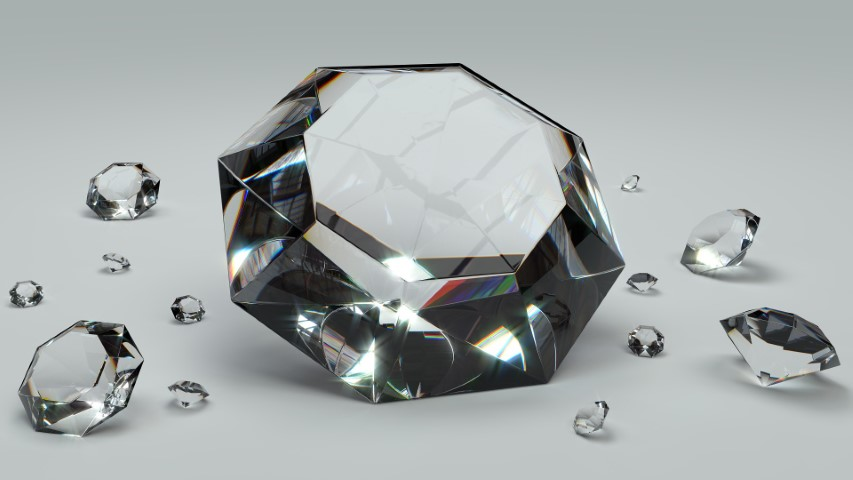

Bild von <a href="https://pixabay.com/de/users/colin00b-346653/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Colin Behrens</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Pixabay</a>

# 0  | Install & Import
***

<p><font color='black' size="5">
Gradio
</font></p>



Gradio ist eine Open-Source-Webplattform, die es Benutzern ermöglicht, benutzerdefinierte Schnittstellen für Machine-Learning-Modelle zu erstellen und zu teilen, ohne dass dafür Webentwicklungsfähigkeiten erforderlich sind. Mit Gradio können Benutzer schnell interaktive Demos erstellen, die Leistung ihres Modells visualisieren und ihre Modelle mit anderen teilen. Die Plattform unterstützt mehrere beliebte Machine-Learning-Bibliotheken, einschließlich TensorFlow, PyTorch und scikit-learn, und bietet eine einfache API für Entwickler, um ihre Modelle in Gradio zu integrieren. Gradio wird häufig für Prototyping, Modell-Debugging und den Bau einfacher ML-Anwendungen verwendet.


[Doku Gradio](https://gradio.app/)

In [ ]:
# Install
!uv pip install --system -q pypmml nyoka

In [ ]:
# Import
import pandas as pd
from pandas import read_csv, DataFrame, to_numeric

from sklearn.preprocessing import Ordinalcoder

from pypmml import Model
import nyoka
import xml.etree.ElementTree as ET

from gradio import Interface
from gradio.components import Slider, Radio, Dropdown, Number, Textbox

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
***


# 2 |  Prepare

---

# 3 |  Modeling
---

# 4 | Evaluate
---


# 5 | Deploy
---

<p><font color='black' size="5">
Modell laden
</font></p>

In [ ]:
# Datei von GitHub kopieren
!curl -L https://raw.githubusercontent.com/ralf-42/ML_Intro/main/04%20model/diamonds-model.pmml -o diamonds-model.pmml

In [ ]:
model = Model.fromFile("/content/diamonds-model.pmml")

<p><font color='black' size="5">
Abfragefunktion für DataApp
</font></p>

In [ ]:
cut_seq = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_seq = ["J", "I", "H", "G", "F", "E", "D"]
clarity_seq = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

In [ ]:
def predict_diamonds(*args):
    feature_vector = DataFrame(
        [args]
    )  # Liste in Liste umwandeln, um eine Zeile zu bilden
    feature_vector.columns = [
        "Carat",
        "Cut",
        "Color",
        "Clarity",
        "Depth",
        "Table",
    ]  # Beispielhafte Spaltennamen

    # Konvertiere numerische Spalten
    feature_vector = feature_vector.apply(to_numeric, errors="ignore")

    # Trenne kategoriale und numerische Spalten
    cat_col = feature_vector.select_dtypes(exclude="number").columns

    # Ordinalcoder korrekt zuweisen
    cat_seq = [cut_seq, color_seq, clarity_seq]
    coder = Ordinalcoder(categories=cat_seq)
    feature_vector[cat_col] = coder.fit_transform(feature_vector[cat_col])

    # Vorbereitung für die Vorhersage
    prepared_features = (
        feature_vector.values
    )  # direkt .values verwenden, um das Array zu erhalten

    # Beispiel Modell-Vorhersage (Modell-Definition hier fiktiv)
    prediction = model.predict(prepared_features)
    return f"{(prediction[0])[0]:,.2f}"

In [ ]:
# Test der Funktion
predict_diamonds(0.7, 'Very Good', 'F', 'SI1', 63.5, 56.0)
# 2,305.27

<p><font color='black' size="5">
App Design
</font></p>

In [ ]:
interface = Interface(
    fn=predict_diamonds,
    inputs=[
        Slider(label="Carat", minimum=0.2, maximum=5.0, step=0.1, value=0.7),
        Radio(label="Cut", choices=cut_seq, value="Very Good"),
        Dropdown(label="Color", choices=color_seq, value="F"),
        Dropdown(label="Clarity", choices=clarity_seq, value="SI1"),
        Slider(
            label="Total Deapth Percentage",
            minimum=43.0,
            maximum=79.0,
            step=0.5,
            value=63.5,
        ),
        Slider(label="Table", minimum=43.0, maximum=95.0, step=0.5, value=56.0),
    ],
    outputs=Textbox(label="Schätzpreis: "),
    title="Schätzpreis für Diamanten",
    description='<p style="text-align: center";>Demo, liefert möglicherweise ungenaue oder falsche Informationen über Preise </br><b>- Alle Angaben ohne Gewähr - </b></p>',
    allow_flagging="never",
)


<p><font color='black' size="5">
Create a local link
</font></p>

In [ ]:
interface.launch()

# Inhalt aus: `B930-save-load-keras-sinus-multi.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Zeitreihenanalyse - Neuronale Netze RNN - LSTM - Sinus
</b></font> </br></p>

---


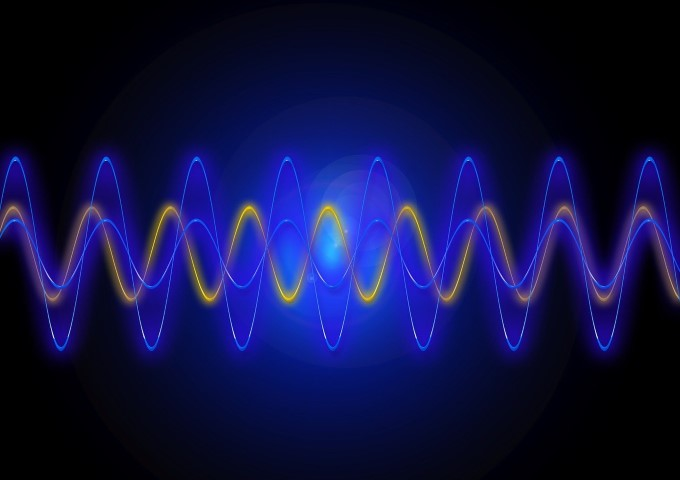

Bild von <a href="https://pixabay.com/de/users/geralt-9301/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=567757">Gerd Altmann</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=567757">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import DataFrame, read_csv, concat

from sklearn.model_selection import train_test_split

import keras
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense
from keras.models import load_model
from keras.utils import set_random_seed, plot_model

from tensorflow import keras
from tensorflow.config.experimental import enable_op_determinism
import tensorflow as tf

import plotly.express as px

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---   


Ein synthetischer Datensatz, der 10 Merkmale enthält und den Verlauf einer Sinuskurve m/o Trend hat. Funktionen alternativ ausführen!

In [ ]:
# @title
# @markdown   <p><font size="4" color='green'>  Synthetische Daten Sinus ohne Trend</font> </br></p>
# def create_dataframe(n_samples, cycles=5):
#     """
#     Erstellt einen DataFrame mit n_samples Datenpunkten, wobei die Zielgröße
#     eine Sinuskurve repräsentiert und die Merkmale M1-M10 darauf basierende Transformationen sind.

#     Parameters:
#     - n_samples: int, die Anzahl der zu generierenden Datenpunkte.

#     Returns:
#     - df: pandas DataFrame, der die generierten Daten enthält.
#     """
#     import numpy as np
#     import pandas as pd
#     # Basis für die Zielgröße
#     time = np.linspace(0, cycles * 2 * np.pi, n_samples)
#     target = np.sin(time)  # Zielgröße

#     # Erzeugen von Merkmalen, die direkt oder indirekt von der Zielgröße abgeleitet sind
#     features = {
#         'M1': np.sin(time),
#         'M2': np.cos(time),
#         'M3': np.sin(time)**2,
#         'M4': np.cos(time)**2,
#         'M5': np.sin(time + np.pi/4),
#         'M6': np.sin(time - np.pi/4),
#         'M7': np.cos(time + np.pi/4),
#         'M8': np.cos(time - np.pi/4),
#         'M9': np.sin(2*time),
#         'M10': np.cos(2*time)
#     }

#     # Erstellen des DataFrames
#     data = DataFrame(features)
#     data['target'] = target

#     return data

In [ ]:
# @title
# @markdown   <p><font size="4" color='green'>  Synthetische Daten Sinus mit Trend</font> </br></p>
def create_dataframe_trend(n_samples, cycles=5, trend_slope=0.01):
    """
    Erstellt einen DataFrame mit n_samples Datenpunkten, wobei die Zielgröße
    eine Sinuskurve repräsentiert und die Merkmale M1-M10 darauf basierende Transformationen sind.

    Parameters:
    - n_samples: int, die Anzahl der zu generierenden Datenpunkte.
    - trend_slope: float, die Steigung des linearen Trends.

    Returns:
    - df: pandas DataFrame, der die generierten Daten enthält.
    """
    import numpy as np
    import pandas as pd

    # Basis für die Zielgröße
    time = np.linspace(0, cycles * 2 * np.pi, n_samples)
    target = np.sin(time) + trend_slope * time  # Zielgröße mit linearem Trend

    # Erzeugen von Merkmalen, die direkt oder indirekt von der Zielgröße abgeleitet sind
    features = {
        "M1": np.sin(time),
        "M2": np.cos(time),
        "M3": np.sin(time) ** 2,
        "M4": np.cos(time) ** 2,
        "M5": np.sin(time + np.pi / 4),
        "M6": np.sin(time - np.pi / 4),
        "M7": np.cos(time + np.pi / 4),
        "M8": np.cos(time - np.pi / 4),
        "M9": np.sin(2 * time),
        "M10": np.cos(2 * time),
    }

    # Erstellen des DataFrames
    data = DataFrame(features)
    data["target"] = target

    return data

In [ ]:
# Erzeugen von x Datenpunkten mit y Zyklen
# Beispiel: 52 Woche x 5 Jahre → 260, 5
#
# data = create_dataframe(520, 10) # ohne Trend
data = create_dataframe_trend(520, 10, 0.001)  # mit Trend

<p><font color='black' size="5">
EDA (Exploratory Data Analysis)   
</font></p>

<p><font color='black' size="4">
Visualisierung der Daten
</font></p>

In [ ]:
fig = px.line(data, y="target", title="Grundprinzip", width=1000, height=500)
fig.show()

In [ ]:
target = data.pop("target")

# **2 | Prepare**
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>


<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.2, shuffle=False
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
Zufallszahl initialisieren
</font></p>

In [ ]:
set_random_seed(42)
enable_op_determinism()

<p><font color='black' size="5">
Übergreifende Parameter
</font></p

In [ ]:
past_steps = 52
future_steps = 52
num_features = 10


<p><font color='black' size="5">
Aufbau der Zeitscheiben
</font></p>

In [ ]:
generator = TimeseriesGenerator(
    data_train, target_train, length=past_steps, batch_size=future_steps
)

# # Beispiel erste Zeitscheibe
x, y = generator[0]
print(x.shape, y.shape)

<p><font color='black' size="5">
Modellaufbau
</font></p>

[Core layers](https://keras.io/api/layers/core_layers/)    
[Recurrent layers](https://keras.io/api/layers/recurrent_layers/)   
[Layer activation functions](https://keras.io/api/layers/activations/)   


In [ ]:
model = Sequential(name="Zeitreihenanalyse")
model.add(Input(shape=(past_steps, num_features)))
model.add(LSTM(64, activation="relu", return_sequences=True))
model.add(LSTM(32, activation="relu", return_sequences=False))
model.add(Dense(1))

In [ ]:
model.summary()

In [ ]:
# Visualisierung neuronales Netz
plot_model(
    model,
    to_file="nn_structure.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    dpi=100,
    expand_nested=True,
    show_layer_activations=True
)

In [ ]:
# Anzahl Parameter je Layer
for layer in model.layers:
    print(f"{layer.name}: {layer.count_params()} Parameter")


<p><font color='black' size="5">
Compile
</font></p>

In [ ]:
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

<p><font color='black' size="5">
Callbacks
</font></p>

In [ ]:
early = EarlyStopping(monitor="mae", patience=2)
check = ModelCheckpoint(filepath="model.keras", monitor="mae", save_best_only=True)

<p><font color='black' size="5">
Training
</font></p>

In [ ]:
model.fit(generator, epochs=5, batch_size=256, callbacks=[early, check])

In [ ]:
save_history = model.history.history

<p><font color='black' size="5">
Loss-Entwickung
</font></p>

In [ ]:
title_ = "Loss-Entwicklung"
px.line(
    y=save_history["loss"],
    title=title_,
    labels={"x": "Epochen", "y": "Loss-Wert"},
    width=800,
    height=400,
)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
### Bestes Modell laden
model = load_model("model.keras")

In [ ]:
# Einfache Vorhersage: Istdaten aus dem TestSet (Merkmale) werden werden zur Vorhersage eines Monats verwendet
prediction_generator = TimeseriesGenerator(
    data_test.values, target_test.values, length=past_steps, batch_size=future_steps
)

# Beispiel erste Zeitscheibe
x, y = prediction_generator[0]
print(x.shape, y.shape)

In [ ]:
# Vorhersagen machen
predictions = model.predict(prediction_generator)

In [ ]:
predictions.shape

<p><font color='black' size="5">
Vergleich Zeitreihen
</font></p>

In [ ]:
cube = DataFrame(target_test[future_steps:])  # Target ist x Perioden zu lang
cube["Predict"] = predictions

In [ ]:
fig = px.line(
    cube,
    y=["target", "Predict"],
    title="Zeitreihenanalyse - Target vs. Predict",
    width=1200,
    height=500,
)
fig.show()

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

<p><font color='black' size="5">
Modell speichern
</font></p>

In [ ]:
model.save("model.keras")

In [ ]:
del model

<p><font color='black' size="5">
Modell einlesen
</font></p>

In [ ]:
new_model = load_model("model.keras")

In [ ]:
new_model.summary()

In [ ]:
new_model.get_weights()

# Inhalt aus: `B940-save-load-dt-diamonds.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
DecisionTreeRegressor - Diamonds
</b></font> </br></p>

---


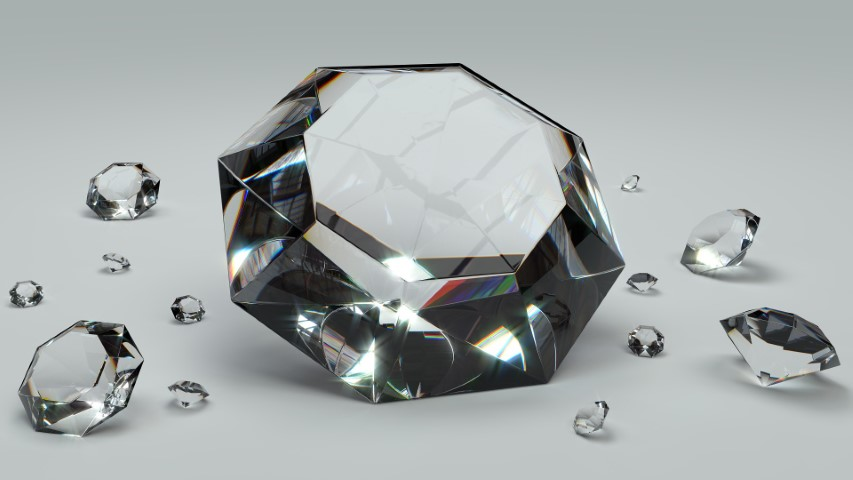

Bild von <a href="https://pixabay.com/de/users/colin00b-346653/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Colin Behrens</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install
!uv pip install --system -q nyoka pypmml

In [ ]:
# Import
from pandas import read_csv, DataFrame

from sklearn.preprocessing import Ordinalcoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

from nyoka import skl_to_pmml
from pypmml import Model

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---

Dieser klassische Datensatz enthält die Preise und andere Attribute von fast 54.000 Diamanten.



[DataSet](https://www.openml.org/search?type=data&status=active&id=42225)

[Info](https://www.kaggle.com/datasets/shivam2503/diamonds)


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/diamonds.csv",
    usecols=[
        "carat",
        "cut",
        "color",
        "clarity",
        "depth",
        "table",
        "price",
    ],
)

In [ ]:
data = df.copy()
target = data.pop("price")

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

# 2 |  Prepare

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Train-Test-Split durchführen</br>
✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
cat_seq = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    ["J", "I", "H", "G", "F", "E", "D"],
    ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
]
data[cat_col] = Ordinalcoder(categories=cat_seq).fit_transform(data[cat_col])

<p><font color='black' size="5">
Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.3, random_state=42
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [ ]:
model = DecisionTreeRegressor(max_depth=5)

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>


<p><font color='black' size="5">
Prediction
</font></p>


In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
Bestimmtheitsmass
</font></p>

In [ ]:
r2 = r2_score(target_train, target_train_pred)
print(f"Modell: {model} -- Train --- Bestimmtheitsmass: {r2:5.2f}")

In [ ]:
r2 = r2_score(target_test, target_test_pred)
print(f"Modell: {model} -- Test --- Bestimmtheitsmass: {r2:5.2f}")

<p><font color='black' size="5">
Mean Absolut Error
</font></p>

In [ ]:
mae = mean_absolute_error(target_test, target_test_pred)
print(f"Modell: {model} -- Test -- Mean Absolute Error: {mae:5.2f}")

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

<p><font size="5">
Save - 2 Versionen
</p>

In [ ]:
# import joblib
# joblib.dump(model, '/content/diamonds-model.pkl')

In [ ]:
# save the model to PMML
pipeline_ = Pipeline([("estimator", model)])
skl_to_pmml(
    pipeline=pipeline_,
    col_names=data_test.columns,
    pmml_f_name="/content/diamonds-model.pmml",
)

<p><font color='black' size="5">
Load - 2 Versionen
</font></p>

In [ ]:
# import joblib
# model_geladen = joblib.load('/content/diamonds-model.pkl')

In [ ]:
model_geladen = Model.fromFile("/content/diamonds-model.pmml")

<p><font size="5">
Prognose
</p>

In [ ]:
one = data_test.iloc[[3333]]
one

In [ ]:
target_test.iloc[3333]

In [ ]:
prediction = model_geladen.predict(one)
print(f"Prognose: {prediction.predicted_target[0]:,.2f}")

# Inhalt aus: `B950-save-load-rf-diamonds.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Supervised Learning - Random Forest - Diamonds
</b></font> </br></p>

---


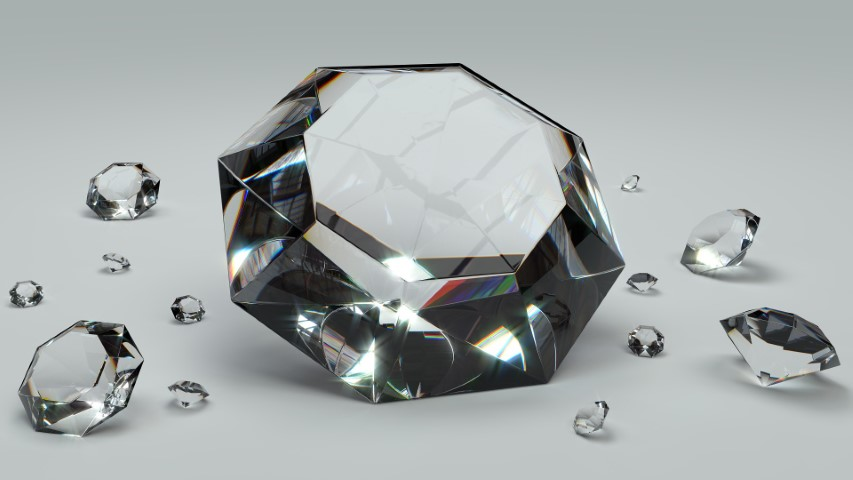

Bild von <a href="https://pixabay.com/de/users/colin00b-346653/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Colin Behrens</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame

from sklearn.preprocessing import Ordinalcoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.subplots as sp

from yellowbrick.regressor import residuals_plot
from yellowbrick.regressor import prediction_error
from yellowbrick.model_selection import feature_importances

import joblib

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---

Dieser klassische Datensatz enthält die Preise und andere Attribute von fast 54.000 Diamanten.



[DataSet](https://www.openml.org/search?type=data&status=active&id=42225)

[Info](https://www.kaggle.com/datasets/shivam2503/diamonds)


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/diamonds.csv",
    usecols=[
        "carat",
        "cut",
        "color",
        "clarity",
        "depth",
        "table",
        "price",
    ],
)

In [ ]:
data = df.copy()
target = data.pop("price")

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.groupby("cut").count()

In [ ]:
data.groupby("color").count()

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Plotly
</font></p>

In [ ]:
title_ = "Depth"
b1 = px.box(data["depth"], title=title_, width=600, height=600)

title_ = "Carat"
b2 = px.box(data["carat"], title=title_, width=600, height=600)

title_ = "Table"
b3 = px.box(data["table"], title=title_, width=600, height=600)

fig = sp.make_subplots(rows=1, cols=3, subplot_titles=("Depth", "Carat", "Table"))

for trace in b1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in b2.data:
    fig.add_trace(trace, row=1, col=2)

for trace in b3.data:
    fig.add_trace(trace, row=1, col=3)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text="Box-Plots")

# Plot anzeigen
fig.show()

# 2 |  Prepare

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Train-Test-Split durchführen</br>
✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
cat_seq = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    ["J", "I", "H", "G", "F", "E", "D"],
    ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
]
data[cat_col] = Ordinalcoder(categories=cat_seq).fit_transform(data[cat_col])

<p><font color='black' size="5">
Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.3, random_state=42
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# 3 |  Modeling
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [ ]:
model = RandomForestRegressor()

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>


<p><font color='black' size="5">
Prediction
</font></p>


In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
Bestimmtheitsmass
</font></p>

In [ ]:
r2 = r2_score(target_train, target_train_pred)
print(f"Modell: {model} -- Train --- Bestimmtheitsmass: {r2:5.2f}")

In [ ]:
r2 = r2_score(target_test, target_test_pred)
print(f"Modell: {model} -- Test --- Bestimmtheitsmass: {r2:5.2f}")

<p><font color='black' size="5">
Mean Absolut Error
</font></p>

In [ ]:
mae = mean_absolute_error(target_test, target_test_pred)
print(f"Modell: {model} -- Test -- Mean Absolute Error: {mae:5.2f}")

<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

# Übernahme Target real & predict
cube["real"] = DataFrame(target_test.values, columns=["real"])
cube["predict"] = DataFrame(target_test_pred, columns=["predict"])

In [ ]:
# Erstellung 2D Features über Dimensionsreduktion PCA - unsupervised
pca = PCA(n_components=2)
pca = pca.fit_transform(data_test)
pca_df = DataFrame(pca)

# Cube um pca erweitern
cube["PCA1"] = pca_df[0]
cube["PCA2"] = pca_df[1]

<p><font color='black' size="5">
Visualisierung real vs predict
</font></p>

In [ ]:
# Boxplot
title_ = "Boxplot real vs predict"
px.box(cube[["real", "predict"]], title=title_, width=600, height=600)

In [ ]:
# Histogramm
title_ = "Histogramm Prices real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=10, title=title_)
fig.update_layout(barmode="group", bargap=0.2, width=800, height=600)
fig.show()

In [ ]:
# 2 x Scatterplots
title_ = "Streupunktdiagramm real"
img1 = px.scatter(
    cube, x="PCA1", y="PCA2", color="real", title=title_, width=600, height=600
)

title_ = "Streupunktdiagramm predict"
img2 = px.scatter(
    cube, x="PCA1", y="PCA2", color="predict", title=title_, width=600, height=600
)

fig = sp.make_subplots(
    rows=1, cols=2, subplot_titles=("Scatterplot real", "Scatterplot predict")
)

for trace in img1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in img2.data:
    fig.add_trace(trace, row=1, col=2)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text="Vergleich real vs predict")

# Plot anzeigen
fig.show()

<p><font color='black' size="5">
Fehlerhafte Vorhersagen
</font></p>

In [ ]:
cube["abs_Abw%"] = abs((cube["real"] - cube["predict"]) / cube["real"] * 100)
%precision 3
cube.head(10).style.format("{:,.1f}", subset=num_col)

In [ ]:
cube.describe().T

In [ ]:
# Histogramm
title_ = "Histogramm absolute Abweichung"
fig = px.histogram(cube, x=["abs_Abw%"], nbins=20, title=title_)
fig.update_layout(barmode="group", bargap=0.2, width=800, height=600)
fig.show()

In [ ]:
_ = residuals_plot(
    model,
    data_train,
    target_train,
    data_test,
    target_test,
    train_color="b",
    test_color="g",
)

In [ ]:
_ = prediction_error(model, data_train, target_train, data_test, target_test)


<p><font color='black' size="5">
Feature Importance
</font></p>

In [ ]:
px.bar(
    x=model.feature_importances_, y=data.columns, width=1000, height=600
).update_yaxes(categoryorder="total ascending")

In [ ]:
_ = feature_importances(model, data, target)

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

<p><font size="5">
Save
</p>

In [ ]:
# schnellste Variante
joblib.dump(model, "/content/diamonds-model.pkl")

<p><font color='black' size="5">
Load
</font></p>

In [ ]:
model_geladen = joblib.load("/content/diamonds-model.pkl")

<p><font size="5">
Prognose
</p>

In [ ]:
target_pred = model_geladen.predict(data_test)
r2 = r2_score(target_test, target_pred)
print(f"Bestimmheitsmaß Testdaten: {r2:.2f}")

In [ ]:
result = DataFrame()
result["real"] = target_test.values
result["pred"] = target_pred
result["%delta"] = (result["real"] - result["pred"]) / result["real"] * 100

# Inhalt aus: `B960_analyse_credit_data_with_gemini.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Analyse Data with Gemini
</b></font> </br></p>

---


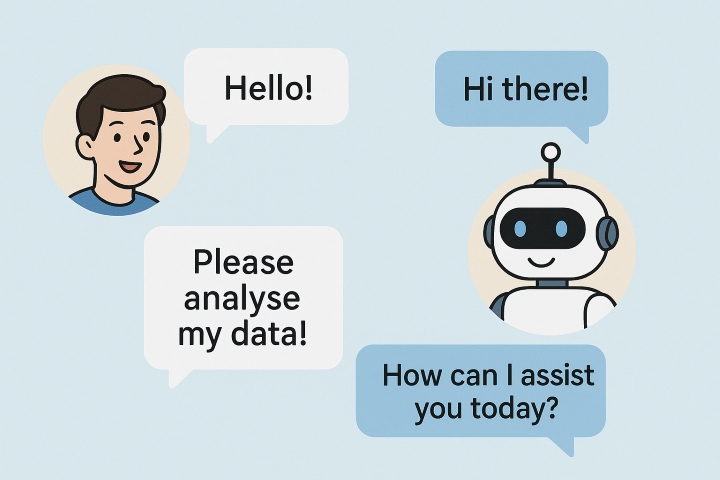

Bild mit ChatGPT erstellt

# 1 | Analyse Kreditwürdigkeit

**Erläuterung zu den Daten in credit.csv:**

Dieser Datensatz enthält einen vereinfachten Ausschnitt an Informationen zu 1000 Kreditanträgen und deren Bonität in Deutschland. Er wird häufig für die Entwicklung und Bewertung von Kreditrisikomodellen verwendet. Hier ist eine kurze Beschreibung der verwendeten Datenfelder:

+ credit_duration_months: Die Laufzeit des Kredits in Monaten.
+ credit_amount_eur: Der beantragte Kreditbetrag in Euro.
+ installment_rate: Die Rate, zu der der Kredit in Prozent des verfügbaren Einkommens zurückgezahlt werden soll.
+ age_years: Das Alter des Kreditnehmers in Jahren.
+ num_existing_credits: Die Anzahl der bestehenden Kredite, die der Kreditnehmer bereits hat.
+ credit_purpose: Der Verwendungszweck des Kredits (z.B. Autokauf, Möbel, Geschäft usw.).
+ credit_risk: Die Bonität des Kreditnehmers, in der Regel als 0 (hohes Risiko/schlechter Kunde) oder 1 (geringes Risiko/guter Kunde) kodiert.   


Quelle: [UCI](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

# 2 | Modellbildung mit Gemini
---

# Task
Analysiere die Daten in "credit.csv".

## Load the data

### Subtask:
Load the data from the `credit.csv` file into a pandas DataFrame.


**Reasoning**:
Import the pandas library and load the data into a pandas DataFrame.



In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/credit.csv')
display(df.head())

## Explore the data

### Subtask:
Display the first few rows, check the data types, and look for missing values.


**Reasoning**:
Display the first few rows, check data types, and look for missing values in the dataframe as instructed.



In [ ]:
display(df.head())
display(df.info())
display(df.isnull().sum())

## Analyze the data

### Subtask:
Perform some basic analysis on the data, such as calculating descriptive statistics and visualizing the distributions of key features.


**Reasoning**:
Calculate and display descriptive statistics for the numerical columns.



In [ ]:
display(df.describe())

**Reasoning**:
Create histograms for the numerical columns to visualize their distributions.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['credit_duration_months', 'credit_amount_eur', 'installment_rate', 'age_years', 'num_existing_credits']
df[numerical_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

**Reasoning**:
Create a bar plot for the 'credit_purpose' column to visualize the frequency of each credit purpose category.



In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='credit_purpose', order = df['credit_purpose'].value_counts().index)
plt.title('Distribution of Credit Purpose')
plt.xlabel('Frequency')
plt.ylabel('Credit Purpose')
plt.show()

**Reasoning**:
Create a count plot for the 'credit_risk' column to visualize the distribution of credit risk categories.



In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='credit_risk')
plt.title('Distribution of Credit Risk')
plt.xlabel('Credit Risk')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['Low Risk (0)', 'High Risk (1)'])
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset contains 1000 entries and 7 columns, including numerical features like `credit_duration_months`, `credit_amount_eur`, `installment_rate`, `age_years`, and `num_existing_credits`, and categorical features like `credit_purpose` and `credit_risk`.
*   There are no missing values in any of the columns.
*   Numerical features such as `credit_duration_months` and `credit_amount_eur` show right-skewed distributions.
*   The dataset contains more instances of low-risk credits (labeled 0) than high-risk credits (labeled 1).
*   The count plot of `credit_purpose` shows the frequency of each credit purpose category, highlighting which purposes are most common.

### Insights or Next Steps

*   Investigate the relationships between the numerical features and the `credit_risk` to understand which factors contribute most to credit risk.
*   Analyze the distribution of `credit_purpose` in relation to `credit_risk` to see if certain purposes are associated with higher risk.


# Task
Analyze "credit.csv", create a classification model with 'credit risk' as the target variable, and evaluate its performance.

## Prepare the data

### Subtask:
Preprocess the data by handling categorical variables and splitting the dataset into training and testing sets.


**Reasoning**:
Convert the 'credit_purpose' column to numerical using one-hot encoding, separate features and target, and split the data into training and testing sets as instructed.



In [ ]:
df_encoded = pd.get_dummies(df, columns=['credit_purpose'], drop_first=True)

X = df_encoded.drop('credit_risk', axis=1)
y = df_encoded['credit_risk']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(X_train.head())
display(y_train.head())

## Choose and train a model

### Subtask:
Select a suitable classification model and train it on the training data.


**Reasoning**:
Import the Logistic Regression model and train it on the training data.



In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

## Evaluate the model

### Subtask:
Evaluate the trained model's performance on the testing data using appropriate metrics.


**Reasoning**:
Use the trained model to make predictions on the test set and evaluate the model's performance using various classification metrics.



In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

## Summary:

### Data Analysis Key Findings

*   The 'credit\_purpose' categorical variable was successfully one-hot encoded.
*   The dataset was split into training (80%) and testing (20%) sets.
*   A Logistic Regression model was trained on the training data.
*   The model achieved an accuracy of 0.7050 on the test set.
*   The model showed a high recall of 0.9362, indicating it is good at identifying positive cases.
*   The precision of the model was 0.7253, and the F1 Score was 0.8173.

### Insights or Next Steps

*   Investigate the `ConvergenceWarning` during model training and consider increasing `max_iter` or using feature scaling to potentially improve convergence and model performance.
*   Explore other classification models and compare their performance to the Logistic Regression model using cross-validation for a more robust evaluation.


# Task
Analysiere "credit.csv", erstelle ein Klassifizierungsmodell für 'credit risk' mit Random Forest, erkläre 'recall' und bewerte das Modell.

## Choose and train a model

### Subtask:
Select the Random Forest classification model and train it on the training data.


**Reasoning**:
Import the RandomForestClassifier model and train it on the training data as instructed.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

## Evaluate the model

### Subtask:
Evaluate the trained Random Forest model's performance on the testing data using appropriate metrics.


**Reasoning**:
Use the trained Random Forest model to make predictions on the test set and evaluate the model's performance using various classification metrics.



In [ ]:
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
print(f'Random Forest Precision: {precision_rf:.4f}')
print(f'Random Forest Recall: {recall_rf:.4f}')
print(f'Random Forest F1 Score: {f1_rf:.4f}')

## Summary:

### Data Analysis Key Findings

*   The Random Forest model achieved an accuracy of approximately 69.50% on the test data.
*   The precision of the model was around 74.39%, while the recall was approximately 86.52%.
*   The F1-score for the model was 80.00%.

### Insights or Next Steps

*   The model shows a higher recall than precision, indicating it is better at identifying positive cases (good credit risk) than avoiding false positives.
*   Further analysis could involve hyperparameter tuning to potentially improve precision without significantly sacrificing recall, depending on the business objective (minimizing missed good risks vs. minimizing false positives that might deny credit to eligible applicants).


# Inhalt aus: `B970_analyse_traffic_mit_gemini.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Analyse Data with Gemini
</b></font> </br></p>

---


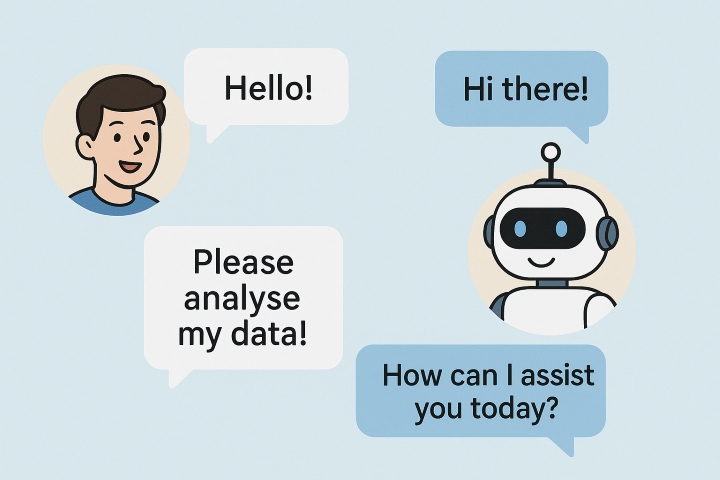

Bild mit ChatGPT erstellt

# 1 | Metro Interstate Traffic Volume
---

Stündliches Verkehrsaufkommen auf der Interstate 94 in westlicher Richtung für die DOT-ATR-Station 301 in Minneapolis und St. Paul, Minnesota, etwa auf halbem Weg zwischen Minneapolis und St. Paul, MN. Stündliche Wetterfunktionen und Feiertage für Auswirkungen auf das Verkehrsaufkommen enthalten.

**Datensatz:**

+ holiday (Kategorische US-amerikanische Feiertage plus regionaler Feiertag, Minnesota State Fair)
+ temp (Numerisch): Durchschnittstemperatur in Kelvin
+ rain_1h (Numerisch): Regenmenge in mm pro Stunde
+ snow_1h (Numerisch): Schneemenge in mm pro Stunde
+ clouds_all (Numerisch): Prozentuale Bewölkung
+ weather_main (Kategorische kurze Textbeschreibung des aktuellen Wetters)
+ weather_description (Kategorische längere Textbeschreibung des aktuellen Wetters)
+ date_time (Datum/Uhrzeit) Uhrzeit der Datenerfassung (Ortszeit CST)
+ traffic_volume (Numerisch): Stündliches Verkehrsaufkommen der I-94 ATR 301 in Richtung Westen

**Citation**     
To use these datasets, please cite the papers:
Liang Zhao, Olga Gkountouna, and Dieter Pfoser. 2019. Spatial Auto-regressive Dependency Interpretable Learning Based on Spatial Topological Constraints. ACM Trans. Spatial Algorithms Syst. 5, 3, Article 19 (August 2019), 28 pages. DOI:https://doi.org/10.1145/3339823


Quelle: [UCI](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

In [ ]:
!uv pip install --system -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
metro_interstate_traffic_volume = fetch_ucirepo(id=492)

# data (as pandas dataframes)
data = metro_interstate_traffic_volume.data.features
target = metro_interstate_traffic_volume.data.targets

# metadata
print(metro_interstate_traffic_volume.metadata)

# variable information
print(metro_interstate_traffic_volume.variables)

In [ ]:
data.holiday.unique()

# 2 | Modellbildung mit Gemini
---

# Task
Analysiere die Daten in "Metro_Interstate_Traffic_Volume.csv".

## Datenvorbereitung

### Subtask:
Bereinigen Sie die Daten, behandeln Sie fehlende Werte und wandeln Sie die Datums-/Zeitspalte in das richtige Format um.


**Reasoning**:
Check the data types and identify missing values in the `data` DataFrame, and fill the missing 'holiday' values with 'None'.



In [ ]:
print(data.info())
data['holiday'] = data['holiday'].fillna('None')
display(data.head())

**Reasoning**:
Import pandas and convert the 'date_time' column to datetime format.



In [ ]:
import pandas as pd
data['date_time'] = pd.to_datetime(data['date_time'])
display(data.info())

## Explorative datenanalyse (eda)

### Subtask:
Führen Sie eine erste Untersuchung der Daten durch, um Muster, Trends und Beziehungen zwischen den Variablen zu verstehen. Dazu gehören die Visualisierung der Verteilung des Verkehrsaufkommens, die Untersuchung des Einflusses von Wetterbedingungen und Feiertagen auf das Verkehrsaufkommen sowie die Analyse zeitbasierter Muster.


**Reasoning**:
Import the necessary libraries for visualization and create a histogram of the traffic volume to understand its distribution.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(target['traffic_volume'], kde=True, bins=50)
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.show()

**Reasoning**:
Examine the influence of weather conditions and holidays on traffic volume by creating boxplots and bar plots.



In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='weather_main', y=target['traffic_volume'], data=data)
plt.title('Traffic Volume by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
sns.barplot(x='holiday', y=target['traffic_volume'], data=data.replace({'holiday': {None: 'None'}})) # Replace None with 'None' for plotting
plt.title('Average Traffic Volume by Holiday')
plt.xlabel('Holiday')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
Analyze time-based patterns by plotting traffic volume over time, and then summarize the findings.



In [ ]:
data_with_target = data.copy()
data_with_target['traffic_volume'] = target['traffic_volume']

plt.figure(figsize=(15, 6))
sns.lineplot(x='date_time', y='traffic_volume', data=data_with_target)
plt.title('Traffic Volume Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Traffic Volume')
plt.show()

data_with_target['hour'] = data_with_target['date_time'].dt.hour
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='traffic_volume', data=data_with_target)
plt.title('Traffic Volume by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Traffic Volume')
plt.show()

data_with_target['dayofweek'] = data_with_target['date_time'].dt.dayofweek
plt.figure(figsize=(12, 6))
sns.boxplot(x='dayofweek', y='traffic_volume', data=data_with_target)
plt.title('Traffic Volume by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Traffic Volume')
plt.show()

data_with_target['month'] = data_with_target['date_time'].dt.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='traffic_volume', data=data_with_target)
plt.title('Traffic Volume by Month')
plt.xlabel('Month')
plt.ylabel('Traffic Volume')
plt.show()

## Feature engineering

### Subtask:
Erstellen Sie neue Features aus vorhandenen Daten, die die Modellleistung verbessern könnten. Zum Beispiel können Sie Features für Stunde, Wochentag, Monat und Jahr aus der Datums-/Zeitspalte extrahieren.


**Reasoning**:
Extract hour, day of week, month, and year from the `date_time` column and create new columns in the `data_with_target` DataFrame.



In [ ]:
data_with_target['hour'] = data_with_target['date_time'].dt.hour
data_with_target['dayofweek'] = data_with_target['date_time'].dt.dayofweek
data_with_target['month'] = data_with_target['date_time'].dt.month
data_with_target['year'] = data_with_target['date_time'].dt.year
display(data_with_target.head())

## Modellauswahl

### Subtask:
Wählen Sie geeignete Modelle für die Vorhersage des Verkehrsaufkommens.


**Reasoning**:
Select appropriate regression models based on the insights from EDA and feature engineering, considering models that can capture seasonal patterns, the impact of holidays and weather conditions, and temporal dependencies. Briefly justify the choice of models based on their strengths and suitability for the task at hand.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotcoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Separate features and target
X = data_with_target.drop(['traffic_volume', 'date_time'], axis=1)
y = data_with_target['traffic_volume']

# Identify categorical and numerical features
categorical_features = ['holiday', 'weather_main', 'weather_description']
numerical_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'dayofweek', 'month', 'year']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotcoder(handle_unknown='ignore'), categorical_features)])

# Create a RandomForestRegressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Create a pipeline that first preprocesses the data and then trains the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', rf_model)])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

In [ ]:
# Get feature importances from the trained model
feature_importances = pipeline.named_steps['regressor'].feature_importances_

# Get the feature names after one-hot encoding
# The get_feature_names_out() method is available from scikit-learn version 1.0
try:
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
except AttributeError:
    # Fallback for older versions of scikit-learn
    # This might not be perfect as it doesn't handle unknown categories explicitly
    ohe_feature_names = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(ohe_feature_names)


# Create a pandas Series for better visualization
feature_importances_series = pd.Series(feature_importances, index=feature_names)

# Sort feature importances in descending order
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

# Print the top 10 most important features
print("Top 10 Most Important Features:")
print(sorted_feature_importances.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sorted_feature_importances.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Display the most important feature at the top
plt.show()

# Task
Analysiere die Daten und erstelle ein RandomForest Modell zur Vorhersage von Staus.

## Definition von stau

### Subtask:
Definieren Sie, was in diesem Datensatz als "Stau" betrachtet werden soll. Dies könnte auf einem Schwellenwert für das Verkehrsaufkommen oder anderen verfügbaren Informationen basieren.


**Reasoning**:
Analyze the distribution of traffic volume to determine a suitable threshold for defining "Stau".



In [ ]:
display(data_with_target['traffic_volume'].describe())

**Reasoning**:
Based on the distribution of the traffic volume, a threshold needs to be defined. The descriptive statistics show the mean, median, and quartiles. A value above the 75th percentile (4933) seems reasonable to consider as "Stau" or congestion, as it represents the upper quartile of traffic volume.



In [ ]:
stau_threshold = 5000
print(f"We define 'Stau' (congestion) as a traffic volume greater than {stau_threshold}.")
print("This threshold was chosen because it is slightly above the 75th percentile of the traffic volume distribution, representing the upper quartile of observed traffic.")

## Datenvorbereitung für stau-klassifizierung

### Subtask:
Erstellen Sie ein neues Ziel-Feature, das angibt, ob ein Stau vorliegt oder nicht, basierend auf der in Schritt 1 definierten Regel. Behandeln Sie die Daten entsprechend für eine Klassifizierungsaufgabe.


**Reasoning**:
Create a new binary column 'is_stau' based on the 'traffic_volume' and 'stau_threshold', and then display the head and value counts of the updated dataframe to verify the new column and its distribution.



In [ ]:
data_with_target['is_stau'] = (data_with_target['traffic_volume'] > stau_threshold).astype(int)
display(data_with_target.head())
display(data_with_target['is_stau'].value_counts())

## Feature engineering (falls erforderlich)

### Subtask:
Überprüfen Sie die vorhandenen Features und erstellen Sie gegebenenfalls neue, die für die Stauvorhersage relevant sein könnten.


## Modellauswahl für klassifizierung

### Subtask:
Wählen Sie geeignete Klassifizierungsmodelle für die Vorhersage von Staus.


**Reasoning**:
Select two classification models suitable for binary classification, considering the dataset characteristics and the class imbalance. Justify the choices and briefly mention how to handle class imbalance.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Selected Classification Models:")
print("1. Logistic Regression: A simple yet effective model for binary classification. It provides interpretable coefficients and can serve as a good baseline. While it assumes linearity, it can still perform reasonably well on complex data.")
print("2. RandomForestClassifier: An ensemble method that can capture non-linear relationships and is generally robust to outliers. It's known for its good performance and provides feature importances, which can be useful for understanding the factors influencing traffic congestion.")

print("\nAddressing Class Imbalance:")
print("The observed class imbalance (more 'no congestion' than 'congestion') can be handled during modeling by:")
print("- Adjusting class weights in the model training to give more importance to the minority class ('congestion').")
print("- Using appropriate evaluation metrics beyond accuracy, such as precision, recall, F1-score, and AUC-ROC, which are less sensitive to class distribution.")

## Modelltraining für klassifizierung

### Subtask:
Trainieren Sie die ausgewählten Klassifizierungsmodelle.


**Reasoning**:
Separate features and target, identify categorical and numerical features, create a column transformer for one-hot encoding, instantiate a RandomForestClassifier with balanced class weights, create a pipeline, and split the data into training and testing sets.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotcoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features and the new target variable 'is_stau'
X = data_with_target.drop(['traffic_volume', 'date_time', 'is_stau'], axis=1)
y = data_with_target['is_stau']

# Identify categorical and numerical features
categorical_features = ['holiday', 'weather_main', 'weather_description']
numerical_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'dayofweek', 'month', 'year']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotcoder(handle_unknown='ignore'), categorical_features)])

# Instantiate a RandomForestClassifier model with balanced class weights
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

# Create a pipeline that first preprocesses the data and then trains the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', rf_model)])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

## Modellevaluierung für klassifizierung

### Subtask:
Bewerten Sie die Leistung der trainierten Klassifizierungsmodelle anhand geeigneter Metriken (z. B. Genauigkeit, Präzision, Recall, F1-Score).


**Reasoning**:
Evaluate the performance of the trained classification model using accuracy, precision, recall, F1-score, and AUC-ROC.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print the metrics
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1}')
print(f'AUC-ROC: {roc_auc}')

## Ergebnisse interpretieren

### Subtask:
Analysieren Sie die Ergebnisse der Modelle, um die wichtigsten Faktoren zu identifizieren, die mit Staus korrelieren.


**Reasoning**:
Access and visualize the feature importances from the trained RandomForestClassifier model to identify the most influential factors in predicting traffic congestion.



In [ ]:
# Access the trained RandomForestClassifier model from the pipeline
rf_classifier_model = pipeline.named_steps['classifier']

# Get feature importances
feature_importances = rf_classifier_model.feature_importances_

# Get the feature names after one-hot encoding
try:
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
except AttributeError:
    # Fallback for older versions of scikit-learn
    # This might not be perfect as it doesn't handle unknown categories explicitly
    ohe_feature_names = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(ohe_feature_names)

# Create a pandas Series for better visualization
feature_importances_series = pd.Series(feature_importances, index=feature_names)

# Sort feature importances in descending order
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

# Print the top 10 most important features
print("Top 10 Most Important Features:")
print(sorted_feature_importances.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sorted_feature_importances.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances for Traffic Congestion Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Display the most important feature at the top
plt.show()

## Summary:

### Data Analysis Key Findings

*   Traffic congestion ("Stau") was defined as a traffic volume greater than 5000, which is slightly above the 75th percentile of the observed traffic volume distribution.
*   The dataset exhibits class imbalance, with significantly more instances of no traffic congestion (0) than congestion (1).
*   Two classification models, Logistic Regression (as a baseline) and RandomForestClassifier, were selected as suitable for the task.
*   A RandomForestClassifier model was trained using a pipeline that included one-hot encoding for categorical features and used balanced class weights to address the data imbalance.
*   The trained RandomForest model achieved an Accuracy of 0.9388, Precision of 0.8785, Recall of 0.8592, F1-Score of 0.8687, and an AUC-ROC of 0.9800 on the test set.
*   The most important features identified by the RandomForest model for predicting traffic congestion are time-based: the hour of the day ('hour') and the day of the week ('dayofweek').
*   Temperature ('temp') is also a significant predictor, following the time-based features in importance.

### Insights or Next Steps

*   The high importance of time-based features suggests that traffic congestion is strongly driven by daily and weekly patterns, likely reflecting commuter behavior and peak hours. Further analysis could focus on specific times of day and days of the week to understand congestion patterns in more detail.
*   Given the strong predictive power of time and temperature, future modeling efforts could explore interaction terms between these features or investigate non-linear relationships to potentially improve performance further.


# Inhalt aus: `B980_analyse_maintenance_mit_gemini.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Analyse Data with Gemini
</b></font> </br></p>

---


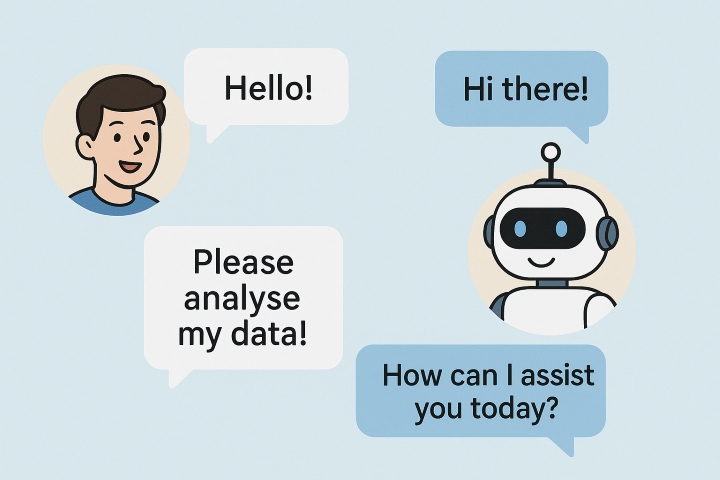

Bild mit ChatGPT erstellt

# 1 | Condition Based Maintenance of Naval Propulsion Plants
---

Die Experimente wurden mit Hilfe eines numerischen Simulators eines Marineschiffes (Fregatte) durchgeführt, das durch einen Gasturbinenantrieb (GT) gekennzeichnet ist. Die verschiedenen Blöcke, aus denen der komplette Simulator besteht (Propeller, Rumpf, GT, Getriebe und Controller), wurden im Laufe des Jahres auf mehreren ähnlichen realen Antriebsanlagen entwickelt und fein abgestimmt. In Anbetracht dieser Beobachtungen stimmen die verfügbaren Daten mit einem möglichen realen Schiff überein.
In dieser Version des Simulators ist es auch möglich, den Leistungsabfall der GT-Komponenten wie GT-Kompressor und Turbinen im Laufe der Zeit zu berücksichtigen.
Das Verhalten des Antriebssystems wurde mit diesen Parametern beschrieben:
- Schiffsgeschwindigkeit (lineare Funktion der Hebelstellung lp).
- Degradationskoeffizient des Kompressors kMc.
- Degradationskoeffizient der Turbine kMt.   

so dass jeder mögliche Degradationszustand durch eine Kombination dieses Tripels (lp,kMt,kMc) beschrieben werden kann.
Der Zerfallsbereich von Verdichter und Turbine wurde mit einem einheitlichen Gitter mit einer Genauigkeit von 0,001 abgetastet, um eine gute Granularität der Darstellung zu erhalten.
Insbesondere für die Diskretisierung des Zerfallszustands des Verdichters wurde der kMc-Koeffizient im Bereich [1; 0,95] und der Turbinenkoeffizient im Bereich [1; 0,975] untersucht.
Die Schiffsgeschwindigkeit wurde untersucht, indem der Bereich der machbaren Geschwindigkeit von 3 Knoten bis 27 Knoten mit einer Granularität der Darstellung gleich Baumknoten untersucht wurde.
Eine Reihe von Messungen (16 Merkmale), die indirekt den Zustand des Systems darstellen, das einem Leistungsabfall unterworfen ist, wurde erfasst und im Datensatz über den Raum des Parameters gespeichert.

**Datensatz:**

Ein 16-Merkmals-Vektor mit den GT-Messwerten im stationären Zustand der Anlage:
+ Hebelstellung (lp) [ ]
+ Schiffsgeschwindigkeit (v) [Knoten]
+ Drehmoment der Gasturbine (GT) (GTT) [kN m]
+ Drehzahl der GT (GTn) [U/min]
+ Drehzahl des Gasgenerators (GGn) [U/min]
+ Drehmoment des Steuerbordpropellers (Ts) [kN]
+ Drehmoment des Backbordpropellers (Tp) [kN]
+ Hochdruck-Turbinenaustrittstemperatur (HP) (T48) [°C]
+ Lufteintrittstemperatur des GT-Kompressors (T1) [°C]
+ Luftaustrittstemperatur des GT-Kompressors (T2) [°C]
+ Druck des Hochdruck-Turbinenaustritts (P48) [bar]
+ Lufteintrittsdruck des GT-Kompressors (P1) [bar]
+ GT Kompressorauslassluftdruck (P2) [bar]
+ GT-Abgasdruck (Pexh) [bar]
+ Turbineneinspritzregelung (TIC) [%]
+ Kraftstoffdurchfluss (mf) [kg/s]

Leistungsverschlechterung:

- GT-Kompressor-Abklingkoeffizient
- GT-Turbinen-Abklingkoeffizient

Ein Abklingkoeffizient (oft bezeichnet als kMc) ist ein numerischer Kennwert, der die Leistungsverschlechterung (Degradation) eines Gas‑Turbinen-Kompressors über die Zeit quantifiziert. Er wird typischerweise im Bereich von 1 (neuwertig) bis etwa 0,95 (deutlich degradierter Zustand) bewertet – Werte nahe 0,95 zeigen eine häufige, aber nicht extreme Degradation an

**License:**
   
Use of this dataset in publications must be acknowledged by referencing the following publication [1]

[1] A. Coraddu, L. Oneto, A. Ghio, S. Savio, D. Anguita, M. Figari, Machine Learning Approaches for Improving Condition?Based Maintenance of Naval Propulsion Plants, Journal of Engineering for the Maritime Environment, 2014, DOI: 10.1177/1475090214540874, (In Press)

@article{Coraddu2013Machine,
    author={Coraddu, Andrea and Oneto, Luca and Ghio, Alessandro and
                 Savio, Stefano and Anguita, Davide and Figari, Massimo},
    title={Machine Learning Approaches for Improving Condition?Based Maintenance of Naval Propulsion Plants},
    journal={Journal of Engineering for the Maritime Environment},
    volume={--},
    number={--},
    pages={--},
    year={2014}
}

This dataset is distributed AS-IS and no responsibility implied or explicit can be addressed to the authors or their institutions for its use or misuse. Any commercial use is prohibited.


Quelle: [UCI](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

In [1]:
!curl -L https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/maintenance_data.txt -o maintenance_data.txt
!curl -L https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/maintenance_features.txt -o maintenance_features.txt


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3368k  100 3368k    0     0  5550k      0 --:--:-- --:--:-- --:--:-- 5548k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   758  100   758    0     0   3413      0 --:--:-- --:--:-- --:--:--  3429


# 2 | Modellbildung mit Gemini
---

**Prompt:**    
Lese die beiden Dateien (/content/maintenance_data.txt, /content/maintenance_features.txt) ein und erstelle eine pandas-DatatFrame mit den Daten. Die Spaltenüberschriften stehen in _feature.txt. Verkürze die Spaltenübersschriften auf die Kurzbezeichnung in den runden Klammern (). Für die Spalten 17 und 18 verwende die Spaltennamen GTCdecay und GTTdecay.

In [2]:
import pandas as pd
import re

# Read the features from the features file
with open('/content/maintenance_features.txt', 'r') as f:
    features_lines = f.readlines()

# Extract the short names from the features and add the two decay columns
column_names = []
for line in features_lines:
    match = re.search(r'\((.*?)\)', line)
    if match:
        column_names.append(match.group(1))

# Add the decay column names
column_names.extend(['GTCdecay', 'GTTdecay'])

# Read the data from the data file, using space as separator
df = pd.read_csv('/content/maintenance_data.txt', sep='\s+', names=column_names)

# Display the first few rows of the DataFrame
display(df.head())

,lp,v,GTT,GTn,GGn,Ts,Tp,T48,T1,T2,P48,P1,P2,Pexh,TIC,mf,GTCdecay,GTTdecay
0,1.138,3.0,289.964,1349.489,6677.380,7.584,7.584,464.006,288.0,550.563,1.096,0.998,5.947,1.019,7.137,0.082,0.95,0.975
1,2.088,6.0,6960.180,1376.166,6828.469,28.204,28.204,635.401,288.0,581.658,1.331,0.998,7.282,1.019,10.655,0.287,0.95,0.975
2,3.144,9.0,8379.229,1386.757,7111.811,60.358,60.358,606.002,288.0,587.587,1.389,0.998,7.574,1.020,13.086,0.259,0.95,0.975
3,4.161,12.0,14724.395,1547.465,7792.630,113.774,113.774,661.471,288.0,613.851,1.658,0.998,9.007,1.022,18.109,0.358,0.95,0.975
4,5.140,15.0,21636.432,1924.313,8494.777,175.306,175.306,731.494,288.0,645.642,2.078,0.998,11.197,1.026,26.373,0.522,0.95,0.975


# Inhalt aus: `template.ipynb`
---

#  0 | Install & Import

In [ ]:
# Install


In [ ]:
# Import


In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

#  1 | Understand

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

#  2 | Prepare

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

#  3 | Modeling

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

#  4 | Evaluate

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

#  5 | Deploy

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>